In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, expon, beta
%matplotlib inline
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

sns.set(font_scale=2)

# 1. Analysis of Deviance

In [2]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [3]:
gf = pd.read_csv('./gforces.txt', sep='\t')
# make all columns lower case:
gf.columns = [c.lower() for c in gf.columns]
gf = gf.sort_values("age")
print(gf)

  subject  age  signs
2      DT   20      0
4      JK   20      1
5      MK   21      0
3      LK   37      1
0      JW   39      0
6      FP   41      1
1      JM   42      1
7      DG   52      1


In [4]:
fit_const = smf.glm('signs ~ 1', 
                    data=gf, 
                    family=sm.families.Binomial()).fit()
fit = smf.glm('signs ~ age', 
              data=gf, 
              family=sm.families.Binomial()).fit()
print(fit.summary())
print(fit_const.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  signs   No. Observations:                    8
Model:                            GLM   Df Residuals:                        6
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4.2173
Date:                Mon, 02 Mar 2026   Deviance:                       8.4345
Time:                        12:06:19   Pearson chi2:                     7.42
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2357
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.9209      2.647     -1.104      0.2

In [5]:
gf.age.min(), gf.age.max()

(np.int64(20), np.int64(52))

In [6]:
X = np.linspace(gf.age.min() - 10, gf.age.max() + 10, 100)
y_const = fit_const.predict(pd.DataFrame(X.reshape(-1, 1), columns=["age"]))
y = fit.predict(pd.DataFrame(X.reshape(-1, 1), columns=["age"]))

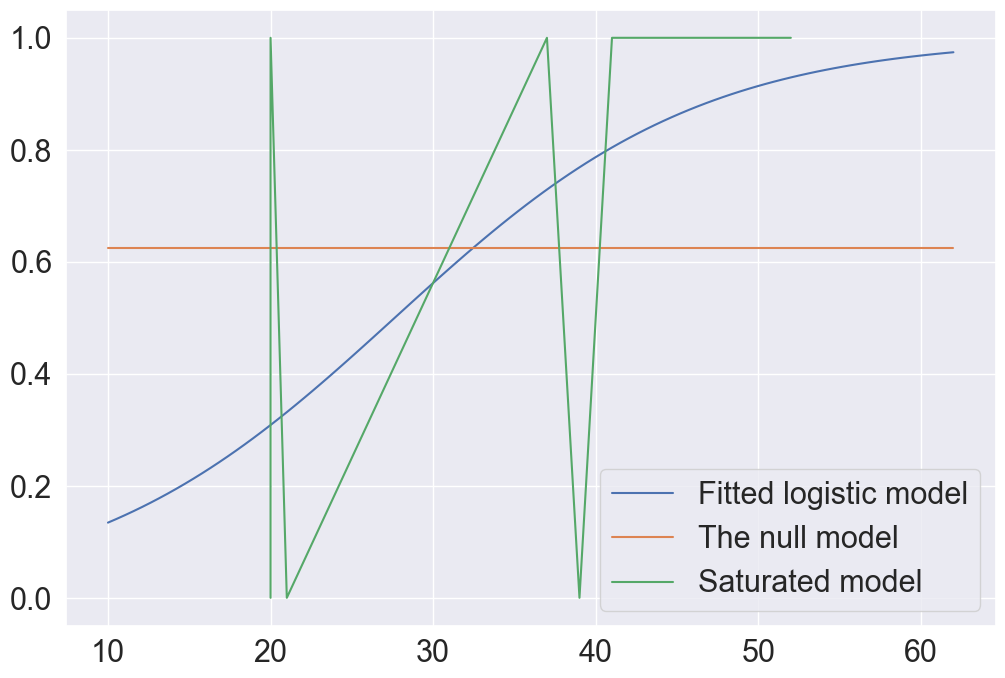

In [7]:
plt.figure(figsize=(12, 8))
plt.plot(X, y, label="Fitted logistic model")
plt.plot(X, y_const, label="The null model")
plt.plot(gf["age"], gf["signs"], label="Saturated model")
plt.legend()
plt.show()

## Deviance

Deviance is the generalization of the Residual Sum of Squares for generalized linear models:

$$
D := -2\,[\ell(\hat{\boldsymbol{\beta}})-\ell_s]\,\phi.
$$

The **null deviance** is the deviance computed when the model includes only the prediction of the mean:

$$
D_0 := -2\,[\ell(\hat{\beta}_0)-\ell_s]\,\phi.
$$

In the case of the exponential family, the deviance can be written as follows:

$$
\begin{aligned}
D &= -\frac{2}{a(\phi)}\sum_{i=1}^n\left(Y_i\hat\theta_i - b(\hat\theta_i) - Y_i g(Y_i) + b(g(Y_i))\right)\phi \\[4pt]
&= \frac{2\phi}{a(\phi)}\sum_{i=1}^n\left(Y_i(g(Y_i) - \hat\theta_i) - b(g(Y_i)) + b(\hat\theta_i)\right).
\end{aligned}
$$

![img](https://bookdown.org/egarpor/PM-UC3M/images/figures/deviance.png)

## Two experiments on a toy problem

In [8]:
def logit(x): 
    return(1. / (1. + np.exp(-x)))

def generate_problem(N=100, beta_1=1.5, beta_2=-1): 
    x_1 = np.random.randn(N)
    x_2 = np.random.randn(N)
    x_3 = np.random.randn(N)
    noise = np.random.randn(N)

    y = x_1 * beta_1 + x_2 * beta_2 + noise
    return np.vstack([x_1, x_2, x_3]).T, np.round(logit(y))

In [9]:
from tqdm import tqdm

deviance_predictor_1 = []
deviance_predictor_2 = []
null_deviance = []

for _ in tqdm(range(1000)):
    try:
        X, y = generate_problem(N=1000)
        data = pd.DataFrame(np.hstack([X, y.reshape(-1, 1)]), columns=["x1", "x2", "x3", "y"])
        fit1 = smf.glm('y ~ x1 + x3', 
                       data=data, 
                       family=sm.families.Binomial()).fit()
        fit2 = smf.glm('y ~ x1 + x2 + x3', 
                       data=data, 
                       family=sm.families.Binomial()).fit()
    except:
        continue
    deviance_predictor_1.append(fit1.deviance)
    deviance_predictor_2.append(fit2.deviance)
    null_deviance.append(fit1.null_deviance)
    
deviance_predictor_1 = np.array(deviance_predictor_1)
deviance_predictor_2 = np.array(deviance_predictor_2)
null_deviance = np.array(null_deviance)

100%|██████████| 1000/1000 [00:08<00:00, 112.21it/s]


Q: What distribution does the deviance have?

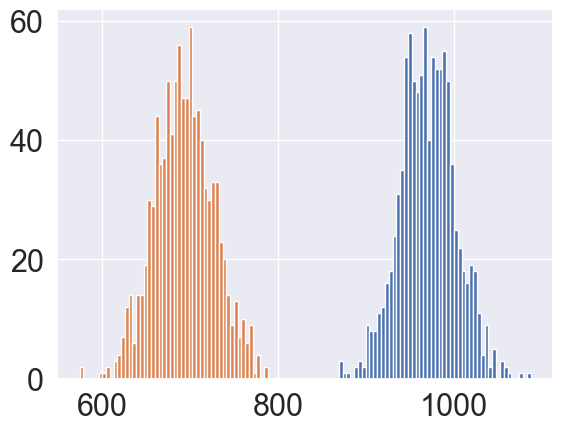

In [10]:
plt.hist(deviance_predictor_1, bins=50);
plt.hist(deviance_predictor_2, bins=50);
# plt.hist(null_deviance, bins=50);

In [11]:
f_hat = (
    (deviance_predictor_1 - deviance_predictor_2) / (fit2.df_model - fit1.df_model) / 
    (deviance_predictor_2 / (len(X) - fit2.df_model - 1))
)

Q: What is the distribution of $\hat f$?

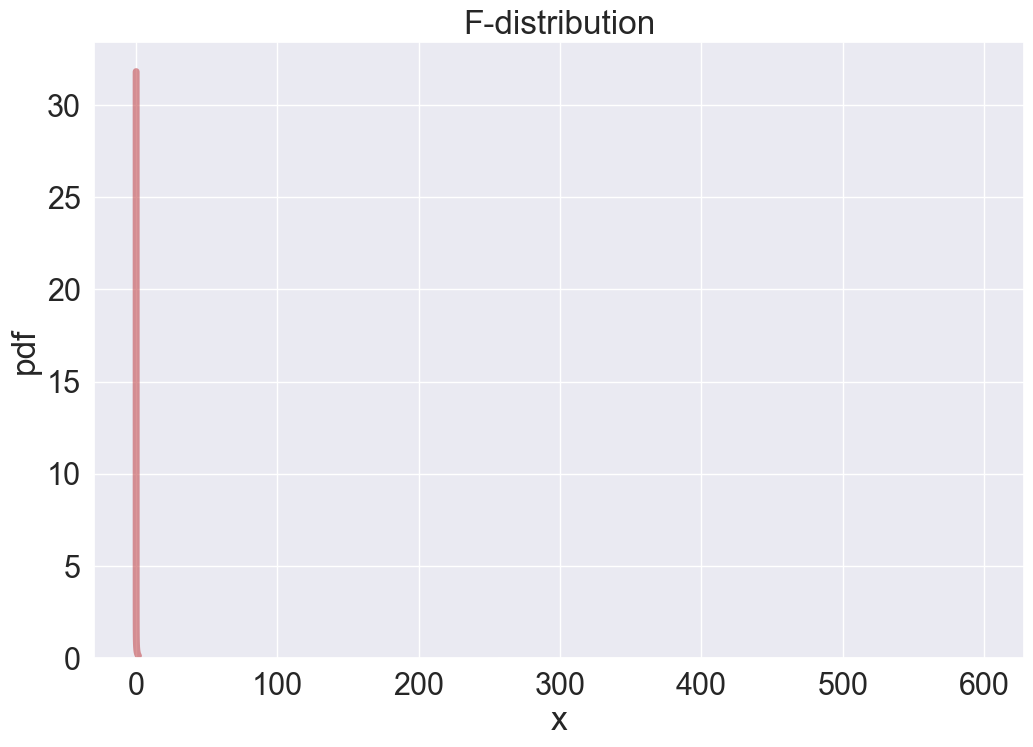

In [13]:
from scipy.stats import f
dfd, dfn = len(X) - 2 - 1, 1 # <>

x = np.linspace(f.ppf(0.01, dfn, dfd),
                f.ppf(0.80, dfn, dfd), 100)

plt.figure(figsize=(12, 8))

plt.hist(
    f_hat, 
    density=True,
    bins=50);
plt.plot(x, f.pdf(x, dfn, dfd), 'r-', lw=5, alpha=0.6, label='f pdf')
plt.title('F-distribution')

plt.xlabel('x')
plt.ylabel('pdf')

plt.show()

## Analysis of Deviance is a generalization of Analysis of Variance for GLMs

$$
H_0: \beta_{p_1+1} = \dots = \beta_{p_2} = 0 \quad\text{vs.}\quad H_1: \beta_j \neq 0 \text{ for some } p_1<j\le p_2.
$$

$$
F = \frac{(D^*_{p_1}-D^*_{p_2})/(p_2-p_1)}{D^*_{p_2}/(n-p_2-1)}
= \frac{(D_{p_1}-D_{p_2})/(p_2-p_1)}{D_{p_2}/(n-p_2-1)}
\ \xrightarrow{a,\,H_0}\ F_{p_2-p_1,\;n-p_2-1}.
$$

# 2. ROC-AUC

## 2.1 Mann–Whitney test

##### Mann–Whitney test (workhorse algorithm)

The Mann-Whitney criterion is used to compare the distributions of two independent groups, specifically focusing on whether one group tends to have larger values than the other.

The U statistic is computed for two samples X of size $m$ and Y of size $n$ as follows:

0. $U_1 = 0$  
1. Take all pairs $(x,y)$ with $x \in X, \; y \in Y$.  
2. If $x > y$, then $U_1 \mathrel{+}= 1$.  
3. If $x = y$, then $U_1 \mathrel{+}= 0.5$.  
4. Compute $U_2 = mn - U_1$.  
5. $U = \min(U_1, U_2)$

For large sample sizes:

$$
U \sim \mathcal{N}\!\left(\frac{mn}{2},\; \frac{mn(m + n + 1)}{12}\right)
$$

For large samples with ties, the standard deviation is computed as:

$$
\sigma = \sqrt{ \frac{nm}{(m + n) (m + n - 1)} \left[ \frac{(m + n)^3 - (m + n)}{12} - \sum_j \frac{t_j^3 - t_j}{12} \right] }
$$

where $t_j$ is the number of tied observations in the j-th tie group of the combined sample.

#### Notable features of the Mann–Whitney rank test

- **Works for ordinal and continuous data.**  
- **Robust to outliers.**  
- **Related to ROC‑AUC:**

$$
\mathrm{AUC} = \frac{U}{mn}.
$$

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1120984/

## 2.2 ROC-AUC

ROC‑AUC and the Mann–Whitney statistic are related by a simple relation:

$$
\mathrm{ROC\text{-}AUC} = \frac{U}{nm}
$$

Here $U$ is computed from the classifier scores (pairwise comparisons), and $n$ and $m$ are the numbers of positive and negative examples in the dataset, respectively.

In [58]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from scipy.stats import rankdata, tiecorrect, mannwhitneyu


X, y = make_classification(n_samples=200, n_features=10, n_redundant=8, class_sep=0.9, 
                           n_informative=2, random_state=1337)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=1337)

In [59]:
X_train.shape, y_test

((150, 10),
 array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 1, 1]))

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression().fit(X_train, y_train)

y_pred = lr.predict_proba(X_test)[:, 1]

print('ROC-AUC={}'.format(roc_auc_score(y_test, y_pred)))

ROC-AUC=0.9056000000000001


In [61]:
y_test_colors = y_test.copy().astype(object)
y_test_colors[y_test==0] = ['r']
y_test_colors[y_test==1] = ['g']

y_pred_argsorted = np.argsort(y_pred)


y_pred = y_pred[y_pred_argsorted]
y_test_colors = y_test_colors[y_pred_argsorted]
y_test = y_test[y_pred_argsorted]
X_test = X_test[y_pred_argsorted]

In [62]:
y_pred

array([0.0161337 , 0.0337614 , 0.0405033 , 0.04789687, 0.05448303,
       0.06651989, 0.07973748, 0.08151106, 0.08192733, 0.09094501,
       0.1137567 , 0.11586591, 0.15379972, 0.17327591, 0.18971871,
       0.20767113, 0.20998755, 0.23903022, 0.31543982, 0.38314673,
       0.38867946, 0.39546164, 0.39875537, 0.4069938 , 0.46441832,
       0.46906883, 0.51498648, 0.5165327 , 0.57790845, 0.59573865,
       0.61842026, 0.65251513, 0.68584969, 0.76511781, 0.80079075,
       0.80417606, 0.81190604, 0.86264823, 0.88662497, 0.8979693 ,
       0.96159614, 0.97187123, 0.97611941, 0.98070759, 0.9856485 ,
       0.98750536, 0.99141918, 0.99411531, 0.99710746, 0.99958676])

Compute Mann–Whitney with `scipy.stats`

In [63]:
mannwhitneyu?

Signature:
mannwhitneyu(
    x,
    y,
    use_continuity=True,
    alternative='two-sided',
    axis=0,
    method='auto',
    *,
    nan_policy='propagate',
    keepdims=False,
)
Docstring:
Perform the Mann-Whitney U rank test on two independent samples.

The Mann-Whitney U test is a nonparametric test of the null hypothesis
that the distribution underlying sample `x` is the same as the
distribution underlying sample `y`. It is often used as a test of
difference in location between distributions.

Parameters
----------
x, y : array-like
    N-d arrays of samples. The arrays must be broadcastable except along
    the dimension given by `axis`.
use_continuity : bool, optional
    Whether a continuity correction (1/2) should be applied.
    Default is True when `method` is ``'asymptotic'``; has no effect
    otherwise.
alternative : {'two-sided', 'less', 'greater'}, optional
    Defines the alternative hypothesis. Default is 'two-sided'.
    Let *SX(u)* and *SY(u)* be the survival funct

In [64]:
mannwhitneyu(y_pred[y_test==1], y_pred[y_test==0], 
             alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(566.0), pvalue=np.float64(9.157883328039219e-07))

In [65]:
n = np.sum(y_test==1)  # количество объектов положительного класса
m = np.sum(y_test==0)  # количесво объектов отрицательного класса

In [66]:
n, m

(np.int64(25), np.int64(25))

Let's make sure of the equality:

$$\mathrm{ROC-AUC} = \frac{U}{n m }$$

In [67]:
mannwhitneyu(y_pred[y_test==1], y_pred[y_test==0], 
             alternative='two-sided')[0] / (n * m)

np.float64(0.9056)

Great!

Now, to interpret ROC‑AUC we need to extract ranks.

A rank is the position in the sorted array.

In [68]:
ranks = rankdata(y_pred)
pos_ranks = ranks[y_test == 1]

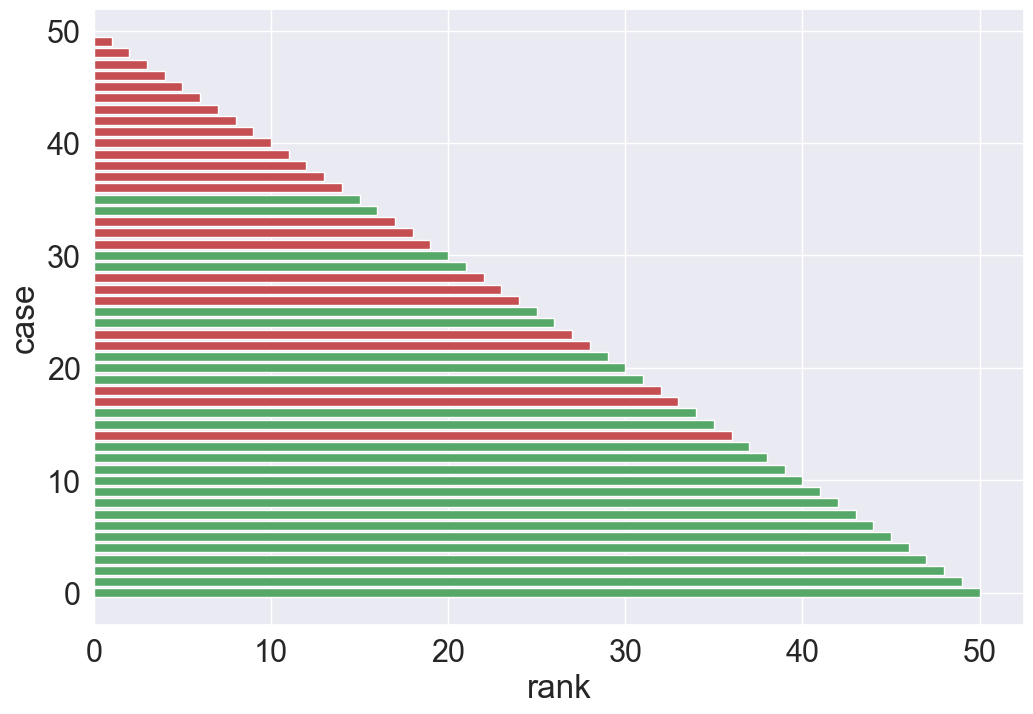

In [69]:
plt.figure(figsize=(12, 8))

plt.barh(np.arange(len(y_pred))[::-1], ranks, color=y_test_colors)

plt.ylabel('case')
plt.xlabel('rank')
plt.show()

In [70]:
x_offset = m + np.arange(1, n + 1) - pos_ranks

In [71]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_pred)

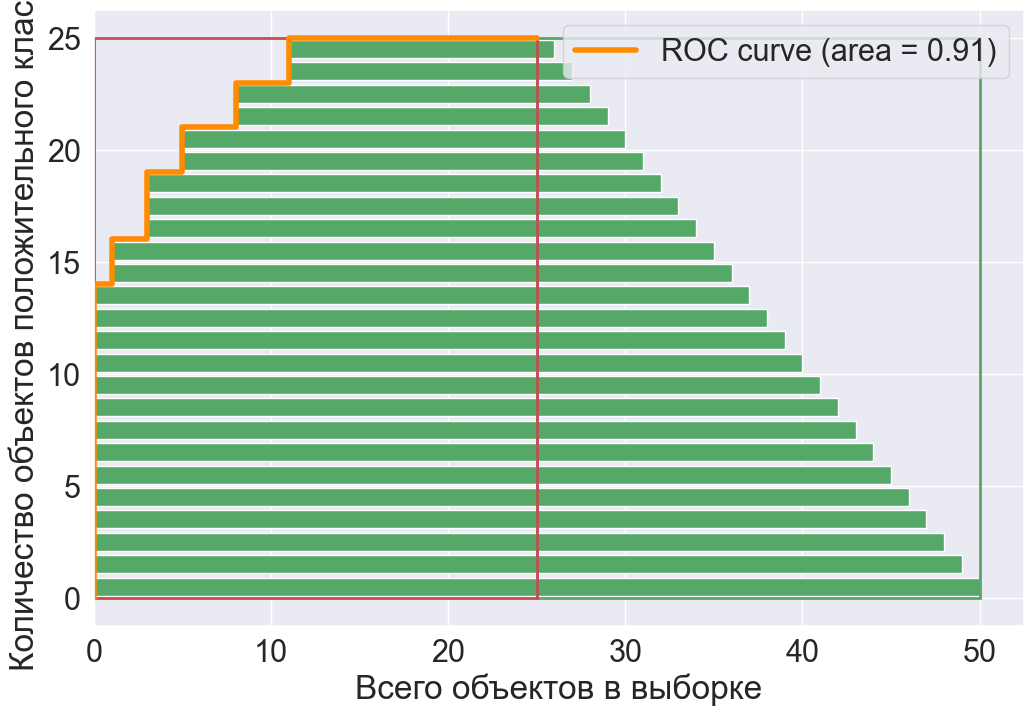

In [33]:
from matplotlib.patches import Rectangle

plt.figure(figsize=(12, 8))
plt.barh(y=np.arange(n)[::-1] + 0.5, width=pos_ranks, left=x_offset, color='g')
plt.plot(m * fpr, n * tpr, color='darkorange',
         label='ROC curve (area = %0.2f)' % roc_auc, lw=4)
plt.gca().add_patch(plt.Rectangle(xy=(m, 0), edgecolor='g',
                                  height=n, width=n, fill=False, linewidth=2))
plt.gca().add_patch(plt.Rectangle(xy=(0, 0), edgecolor='r',
                                  height=n, width=m, fill=False, linewidth=2))
plt.xlabel('Всего объектов в выборке')
plt.ylabel('Количество объектов положительного класса')
plt.legend(loc='best')
plt.show()

In [34]:
x_offset

array([11., 11.,  8.,  8.,  5.,  5.,  3.,  3.,  3.,  1.,  1.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

## Apply this to a real task

Read the data and split it into train/test sets.

In [35]:
X = pd.read_csv('./cell2celltrain.csv')
msk = np.random.rand(len(X)) < 0.8
X_train = X[msk].copy()
X_test = X[~msk].copy()

columns = ['MonthlyRevenue', 'MonthlyMinutes',
           'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes',
           'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues',
           'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
           'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
           'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
           'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
           'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels',
           'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH',
           'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner',
           'BuysViaMailOrder', 'RespondsToMailOffers',
           'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
           'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser',
           'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup',
           'OwnsMotorcycle', 'AdjustmentsToCreditRating', 'HandsetPrice',
           'MadeCallToRetentionTeam', 'CreditRating', 'Occupation',
           'MaritalStatus']

Let's drop the columns `ServiceArea`, `Homeownership`, `PrizmCode`.

In [36]:
drop_columns = ['ServiceArea', 'Homeownership', 'PrizmCode']

X_train.drop(labels=drop_columns, axis=1, inplace=True)
X_test.drop(labels=drop_columns, axis=1, inplace=True)

Encode binary columns as `0/1`.

In [37]:
bin_cols = ['Churn', 'HandsetRefurbished', 'HandsetWebCapable', 'RespondsToMailOffers',
            'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'OptOutMailings', 'NonUSTravel',
            'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser',
            'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'ChildrenInHH', 'MaritalStatus']
def preprocess_bin_cols(X, cols):
    for col in cols:
        X[col] = X[col].apply(lambda x: 1 if x == 'Yes' else 0)
        
        
preprocess_bin_cols(X_train, bin_cols)
preprocess_bin_cols(X_test, bin_cols)

In [38]:
def ohe(X_train, X_test, col):
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

ohe(X_train, X_test, 'CreditRating')
ohe(X_train, X_test, 'Occupation')

Remove NaN values.

In [39]:
X_train[X_train == 'Unknown'] = np.nan
X_train.fillna(0, inplace=True)

X_test[X_test == 'Unknown'] = np.nan
X_test.fillna(0, inplace=True)

Convert to NumPy format.

In [40]:
y_train = X_train.Churn.values
X_train = X_train[columns].values.astype(float)

y_test = X_test.Churn.values
X_test = X_test[columns].values.astype(float)

In [41]:
lr = LogisticRegression().fit(X_train, y_train)

y_pred = lr.predict_proba(X_test)[:, 1]

print('ROC-AUC={}'.format(roc_auc_score(y_test, y_pred)))

ROC-AUC=0.5806741799421034


In [43]:
y_test_colors = y_test.copy().astype(object)
y_test_colors[y_test==0] = ['r']
y_test_colors[y_test==1] = ['g']

y_pred_argsorted = np.argsort(y_pred)

y_pred = y_pred[y_pred_argsorted]
y_test_colors = y_test_colors[y_pred_argsorted]
y_test = y_test[y_pred_argsorted]
X_test = X_test[y_pred_argsorted]

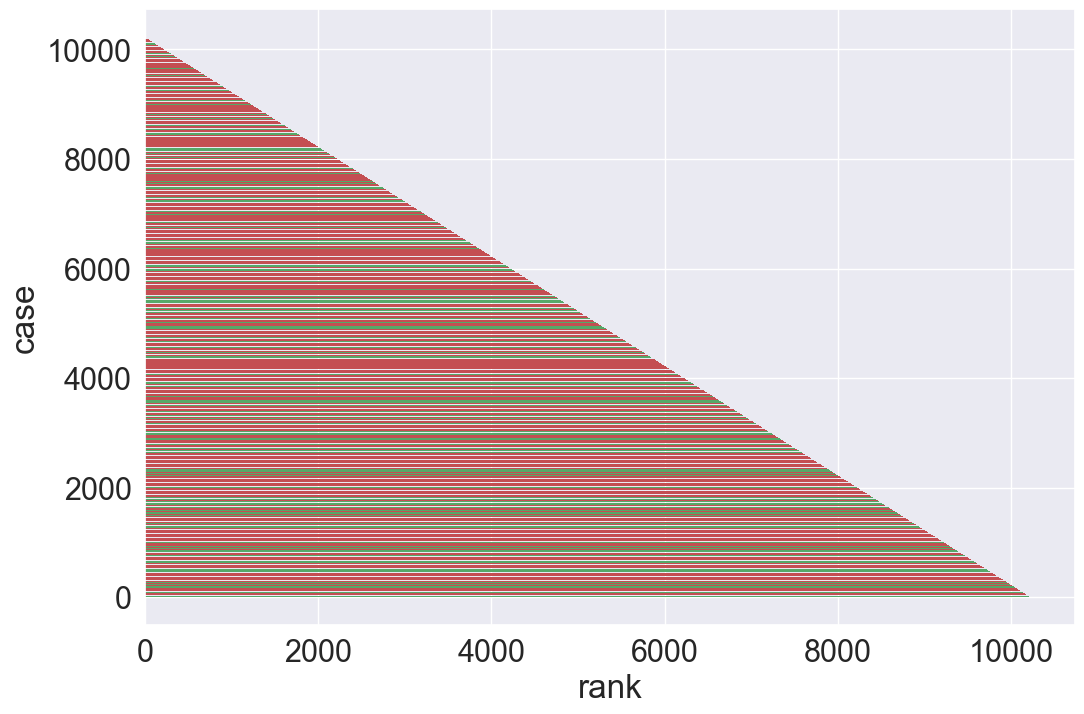

In [44]:
ranks = rankdata(y_pred)
pos_ranks = ranks[y_test == 1]

plt.figure(figsize=(12, 8))

plt.barh(np.arange(len(y_pred))[::-1], ranks, color=y_test_colors, edgecolor='none')

plt.ylabel('case')
plt.xlabel('rank')
plt.show()

In [45]:
n = np.sum(y_test==1)  # количество объектов положительного класса
m = np.sum(y_test==0)  # количесво объектов отрицательного класса

x_offset = m + np.arange(1, n + 1) - pos_ranks

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

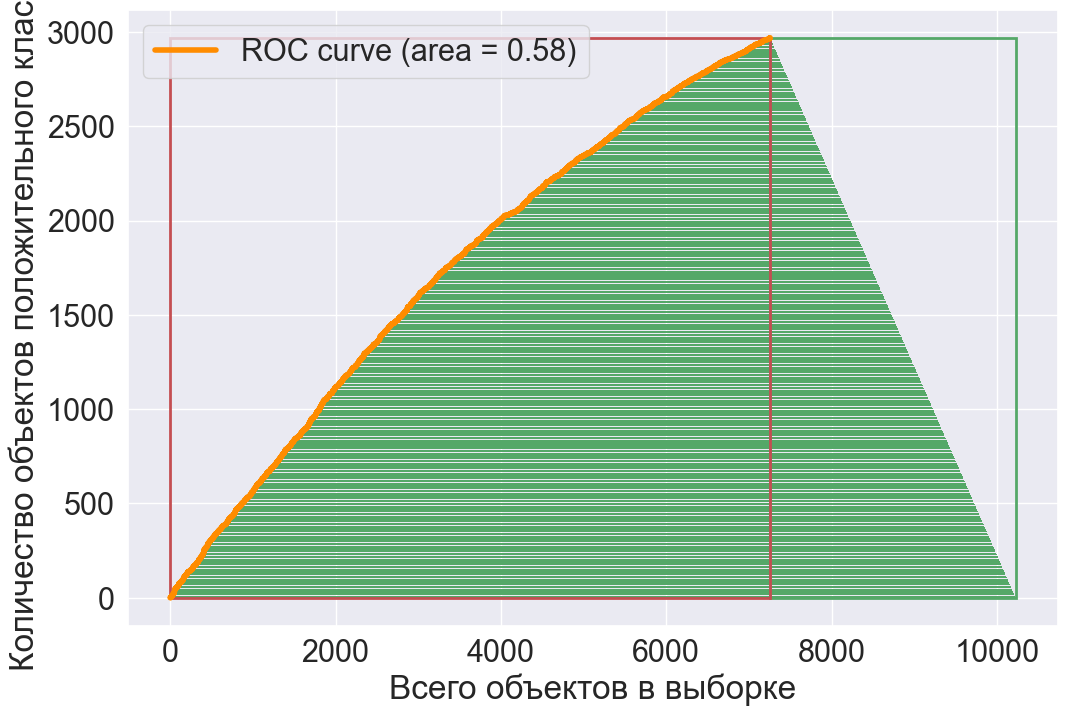

In [47]:
from matplotlib.patches import Rectangle

plt.figure(figsize=(12, 8))
plt.barh(y=np.arange(n)[::-1] + 0.5, width=pos_ranks, left=x_offset, color='g', edgecolor='none')
plt.plot(m * fpr, n * tpr, color='darkorange',
         label='ROC curve (area = %0.2f)' % roc_auc, lw=4)
plt.gca().add_patch(plt.Rectangle(xy=(m, 0), edgecolor='g',
                                  height=n, width=n, fill=False, linewidth=2))
plt.gca().add_patch(plt.Rectangle(xy=(0, 0), edgecolor='r',
                                  height=n, width=m, fill=False, linewidth=2))
plt.xlabel('Всего объектов в выборке')
plt.ylabel('Количество объектов положительного класса')
plt.legend(loc='best')
plt.show()

## 2.3 Three ways to compute variance of ROC-AUC

### 2.3.1 From the limiting distribution of the Mann–Whitney statistic (null case)

For large sample sizes, under the null hypothesis that positive and negative scores
come from the same continuous distribution (so AUC = 0.5 and there are no ties),
the Mann–Whitney statistic $U_1$ has the asymptotic normal distribution

$$
U_1 \approx \mathcal{N}\!\left(\frac{m n}{2},\; \frac{m n (m + n + 1)}{12}\right),
$$

where **$m$** is the number of positive examples and **$n$** is the number of negative examples.

Since $\widehat{\mathrm{AUC}} = U_1/(m n)$, the asymptotic distribution of ROC-AUC is

$$
\widehat{\mathrm{AUC}} \approx \mathcal{N}\!\left(\tfrac{1}{2},\; \frac{m + n + 1}{12\,m n}\right).
$$

We are mainly interested in the standard error estimate:

$$
\widehat{se} \;=\; \sqrt{\frac{m + n + 1}{12\,m n}}.
$$

**Notes**
- This formula does **not** depend on the observed $\widehat{\mathrm{AUC}}$; it is mainly useful for rough planning when AUC is expected to be close to $0.5$.
- If there are ties or AUC is far from $0.5$, use tie corrections or alternative variance estimators (e.g., DeLong).

In [48]:
def roc_auc_variance_from_mann_whitney(n1, n2):
    return (n1 + n2 + 1) / (12 * n1 * n2)

In [49]:
roc_auc_variance_from_mann_whitney(25, 25)

0.0068

### 2.3.2 method ``Mcneil''

https://pubs.rsna.org/doi/10.1148/radiology.143.1.7063747

http://cejsh.icm.edu.pl/cejsh/element/bwmeta1.element.desklight-1f1afc51-6102-491f-a21d-de29ae98ce3b/c/MIBE_T15_z2_36.pdf

![](var_auc.png)

In this context, $\theta$ is the "true" ROC-AUC.

$$\hat{se} = \sqrt{ \frac{ (\hat{AUC} (1 - \hat{AUC}) + (n - 1)(Q_1 - \hat{AUC}^2) + (m - 1)(Q_2 - \hat{AUC}^2) )() }{n m} }$$

Plus:
  * takes into account the received AUC value.

Minus:
* a strong assumption about the normality of the distribution.

In [52]:
def roc_auc_variance(auc, n1, n2):
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    return (auc * (1 - auc) + (n1 - 1) * (q1 - auc**2) + (n2 - 1) * (q2 - auc**2)) / (n1 * n2)

In [53]:
roc_auc_variance(0.5, 25,25)

0.006799999999999999

### 2.3.3 DeLong method

https://www.ncbi.nlm.nih.gov/pubmed/3203132

This method additionally takes into account correlations between positive and negative classes.

In [72]:
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

models = {
    'LogisticRegression': LogisticRegression(),
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

In [73]:
import numpy as np

if not hasattr(np, 'float'):
    np.float = float  # Add np.float as alias for float

from compare_auc_delong_xu import delong_roc_variance
from tqdm import tqdm
auc_var_naives = []
auc_var_params = []
auc_var_delongs = []
aucs = []
model_names = []

for model_name, model in tqdm(models.items()):
    # train model
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    # estimate auc and variance
    auc = roc_auc_score(y_test, y_pred)
    n, m = y_test.sum(), len(y_test) - y_test.sum()
    auc_var_naive = roc_auc_variance_from_mann_whitney(n, m)
    auc_var_param = roc_auc_variance(auc, n, m)
    _, auc_var_delong = delong_roc_variance(y_test, y_pred)
    
    # add stats to lists
    model_names.append(model_name)
    auc_var_naives.append(auc_var_naive)
    auc_var_params.append(auc_var_param)
    auc_var_delongs.append(auc_var_delong)
    aucs.append(auc)
    
auc_var_naives = np.sqrt(np.array(auc_var_naives))
auc_var_params = np.sqrt(np.array(auc_var_params))
auc_var_delongs = np.sqrt(np.array(auc_var_delongs))
aucs = np.array(aucs)

100%|██████████| 3/3 [00:00<00:00, 335.33it/s]


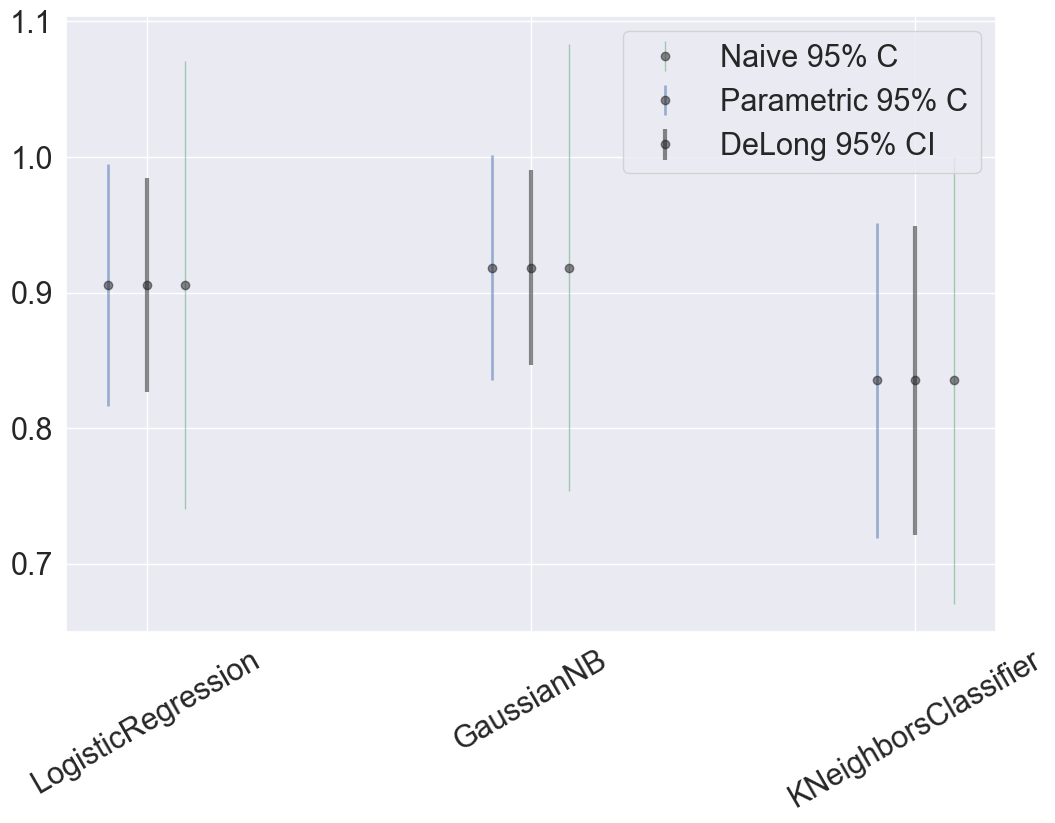

In [74]:
x = np.arange(len(aucs))
plt.figure(figsize=(12, 8))

plt.errorbar(x + 0.1, aucs, 2 * auc_var_naives, fmt='ok', lw=1, alpha=0.5, 
             ecolor='g', label='Naive 95% C')
plt.errorbar(x - 0.1, aucs, 2 * auc_var_params, fmt='ok', lw=2, alpha=0.5, 
             ecolor='b', label='Parametric 95% C')
plt.errorbar(x, aucs, 2 * auc_var_delongs, fmt='ok', lw=3, alpha=0.5, 
             ecolor='k', label='DeLong 95% CI')

plt.xticks(x, model_names, rotation=30)
plt.legend()
plt.show()

### Let's look at the behavior of the ROC-AUC standard deviation for a small sample on an artificial task

The first sample is sampled from:

$$x_1 \sim \mathcal{N}(0, 1)$$

The second sample is sampled from:

$$x_2 \sim \mathcal{N}(2, 1)$$

Then the ideal ROC-AUC can be calculated as follows:

$$\mathrm{ROC-AUC} = p(x_2 > x_1) = p\left(\mathcal{N}(2, 2) > 0\right) = \frac{1}{2} \mathrm{erfc}\left(-\frac{\mu}{\sqrt{2} \sigma}\right) \approx 0.92$$

In [177]:
from scipy import special

In [185]:
mu = 2
sigma = 1
ideal_auc = special.erfc(- mu / (np.sqrt(2) * np.sqrt(sigma**2 + sigma**2))) / 2
ideal_auc

np.float64(0.9213503964748573)

In [186]:
first_type_error_rate = 1 - 0.68
first_type_error_rate

0.31999999999999995

In [187]:
from scipy.stats import norm
def make_classification(n_samples, mu_1=0, sigma_1=sigma, mu_2=mu, sigma_2=sigma):
    X_1 = norm.rvs(loc=mu_1, scale=sigma_1, size=n_samples).reshape(-1, 1)
    X_2 = norm.rvs(loc=mu_2, scale=sigma_2, size=n_samples).reshape(-1, 1)
    X = np.concatenate([X_1, X_2], axis=0)
    Y = np.ones_like(X)
    Y[:len(X_1)] = 0.
    idx = np.random.choice(len(Y), size=len(Y), replace=False)
    return X[idx], Y[idx].reshape(-1)

In [188]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

X, y = make_classification(n_samples=1000)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [189]:
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

def cv_auc_var_ci(model, X, y, B=100, first_type_error_rate=1 - 0.68):
    aucs_std = []
    aucs = []
    for _ in range(B): # q 
        aucs_tmp = cross_val_score(model, X=X, y=y, 
                                   scoring='roc_auc', 
                                   cv=StratifiedKFold(n_splits=10, shuffle=True)) # k
        aucs_std.extend(aucs_tmp)
        aucs.extend(aucs_tmp)
    return np.mean(aucs), np.std(aucs_std), np.percentile(aucs, q=[100 * first_type_error_rate / 2, 100 * (1 - first_type_error_rate / 2)])

In [190]:
from tqdm import tqdm
auc_var_naives = []
auc_var_params = []
auc_var_delongs = []
auc_var_boots = []
auc_ci_lows = []
auc_ci_highs = []
aucs_cv_means = []
aucs = []
model_names = []

for model_name, model in tqdm(models.items()):
    # train model
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    # estimate auc and variance
    auc = roc_auc_score(y_test, y_pred)
    n, m = y_test.sum(), len(y_test) - y_test.sum()
    auc_var_naive = roc_auc_variance_from_mann_whitney(n, m)
    auc_var_param = roc_auc_variance(auc, n, m)
    _, auc_var_delong = delong_roc_variance(y_test, y_pred)
    aucs_cv_mean, auc_var_boot, (auc_ci_low, auc_ci_high) = cv_auc_var_ci(model, X, y, B=50, 
                                                                          first_type_error_rate=first_type_error_rate)
    # add stats to lists
    
    model_names.append(model_name)
    auc_var_naives.append(auc_var_naive)
    auc_var_params.append(auc_var_param)
    auc_var_delongs.append(auc_var_delong)
    auc_var_boots.append(auc_var_boot)
    auc_ci_lows.append(auc_ci_low)
    auc_ci_highs.append(auc_ci_high)
    aucs_cv_means.append(aucs_cv_mean)
    aucs.append(auc)
    
auc_var_naives = np.sqrt(np.array(auc_var_naives))
auc_var_params = np.sqrt(np.array(auc_var_params))
auc_var_delongs = np.sqrt(np.array(auc_var_delongs))
auc_var_boots = np.array(auc_var_boots)
auc_ci_lows = np.array(auc_ci_lows)
auc_ci_highs = np.array(auc_ci_highs)
aucs_cv_means = np.array(aucs_cv_means)
aucs = np.array(aucs)

100%|██████████| 3/3 [00:03<00:00,  1.11s/it]


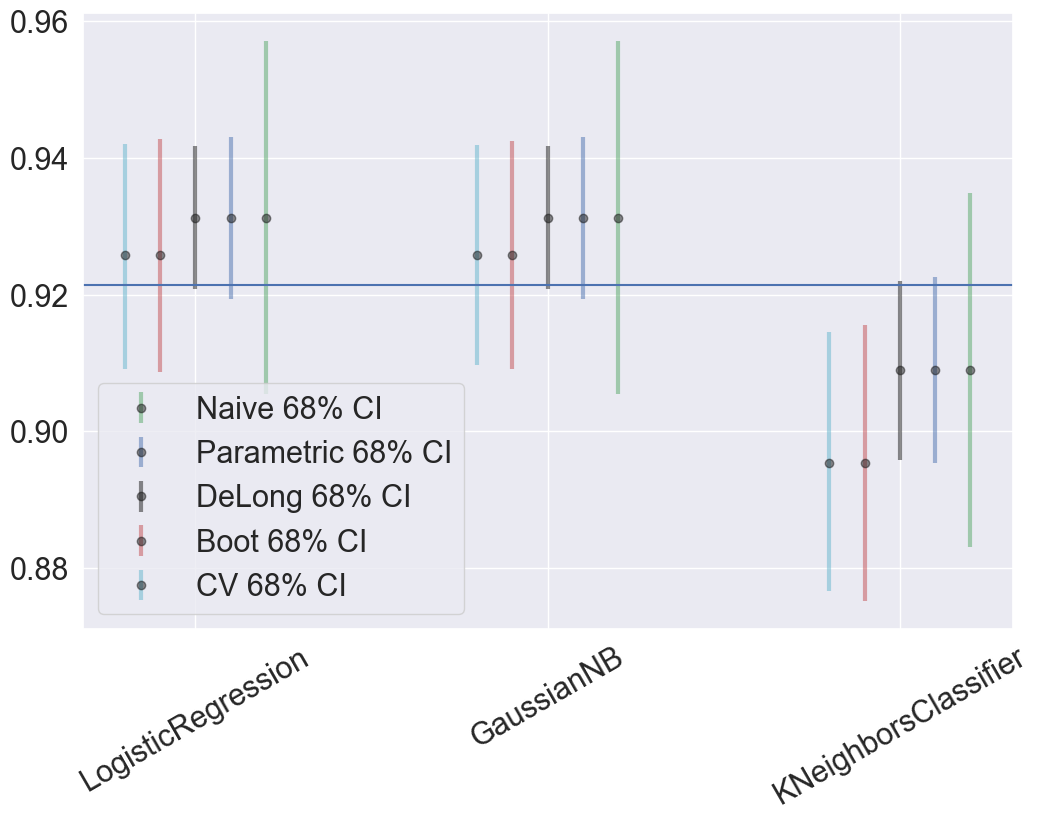

In [191]:
x = np.arange(len(aucs))
plt.figure(figsize=(12, 8))

plt.errorbar(x + 0.2, aucs, auc_var_naives, fmt='ok', lw=3, alpha=0.5, 
             ecolor='g', label='Naive 68% CI')
plt.errorbar(x + 0.1, aucs, auc_var_params, fmt='ok', lw=3, alpha=0.5, 
             ecolor='b', label='Parametric 68% CI')
plt.errorbar(x, aucs, auc_var_delongs, fmt='ok', lw=3, alpha=0.5, 
             ecolor='k', label='DeLong 68% CI')
plt.errorbar(x - 0.1, aucs_cv_means, auc_var_boots, fmt='ok', lw=3, alpha=0.5, 
             ecolor='r', label='Boot 68% CI')
plt.errorbar(x - 0.2, aucs_cv_means, np.array([aucs_cv_means - auc_ci_lows, auc_ci_highs - aucs_cv_means]), 
             fmt='ok', lw=3, alpha=0.5, ecolor='c', label='CV 68% CI')

plt.axhline(ideal_auc)

plt.xticks(x, model_names, rotation=30)
plt.legend()
plt.show()

## Calculate the capture rate for `GaussianNB`

In [192]:
model = models["GaussianNB"]

In [193]:
from tqdm import trange

auc_var_naives = []
auc_var_params = []
auc_var_delongs = []
auc_var_boots = []
auc_ci_lows = []
auc_ci_highs = []
aucs_cv_means = []
aucs = []

for i in trange(100):
    X, y = make_classification(n_samples=1000)
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    # estimate auc and variance
    auc = roc_auc_score(y_test, y_pred)
    n, m = y_test.sum(), len(y_test) - y_test.sum()
    auc_var_naive = roc_auc_variance_from_mann_whitney(n, m)
    auc_var_param = roc_auc_variance(auc, n, m)
    _, auc_var_delong = delong_roc_variance(y_test, y_pred)
    aucs_cv_mean, auc_var_boot, (auc_ci_low, auc_ci_high) = cv_auc_var_ci(
        model, X, y, B=50, first_type_error_rate=first_type_error_rate
    )

    auc_var_naives.append(auc_var_naive)
    auc_var_params.append(auc_var_param)
    auc_var_delongs.append(auc_var_delong)
    auc_var_boots.append(auc_var_boot)
    auc_ci_lows.append(auc_ci_low)
    auc_ci_highs.append(auc_ci_high)
    aucs_cv_means.append(aucs_cv_mean)
    aucs.append(auc)

100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


In [194]:
first_type_error_rate

0.31999999999999995

In [195]:
auc_var_naives = np.sqrt(np.array(auc_var_naives))
auc_var_params = np.sqrt(np.array(auc_var_params))
auc_var_delongs = np.sqrt(np.array(auc_var_delongs))
auc_var_boots = np.array(auc_var_boots)
auc_ci_lows = np.array(auc_ci_lows)
auc_ci_highs = np.array(auc_ci_highs)
aucs_cv_means = np.array(aucs_cv_means)
aucs = np.array(aucs)

In [196]:
((aucs - auc_var_naives < ideal_auc) & (ideal_auc < aucs + auc_var_naives)).mean()

np.float64(0.97)

In [197]:
((aucs - auc_var_params < ideal_auc) & (ideal_auc < aucs + auc_var_params)).mean()

np.float64(0.76)

In [198]:
((aucs - auc_var_delongs < ideal_auc) & (ideal_auc < aucs + auc_var_delongs)).mean()

np.float64(0.73)

In [199]:
((aucs_cv_means - auc_var_boots < ideal_auc) & (ideal_auc < aucs_cv_means + auc_var_boots)).mean()

np.float64(1.0)

In [200]:
((auc_ci_lows < ideal_auc) & (ideal_auc < auc_ci_highs)).mean()

np.float64(1.0)

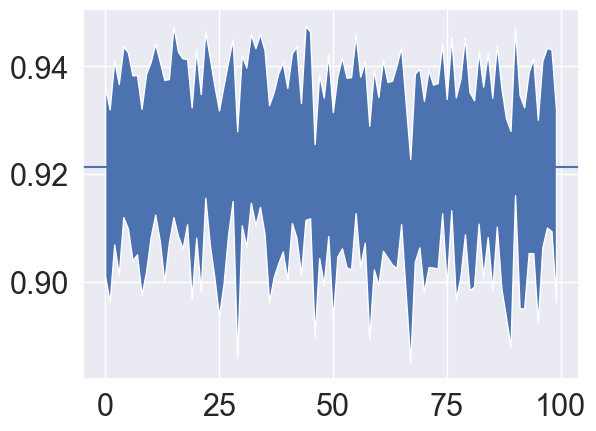

In [201]:
plt.fill_between(np.arange(len(auc_ci_lows)), auc_ci_lows, auc_ci_highs)
plt.axhline(ideal_auc)

Three problems:

  * As we have seen, classical methods of estimating AUC variance are fast, but they give a symmetrical interval;
  * $r\times q-\mathrm{fold}$ CV gives more beautiful intervals, but extremely expensive in time;
  * There is some bias in estimates for `LogisticRegression`.

# 3. Simpson paradox

In [136]:
df = pd.read_csv("paradox.csv")
df = df.drop(df.columns[0], axis=1)
df.columns=["Neuroticism", "Salary", "Education"]

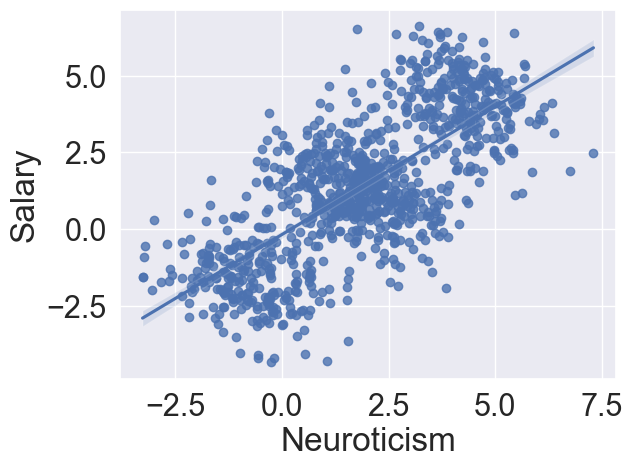

In [137]:
sns.regplot(data=df, x="Neuroticism", y="Salary");

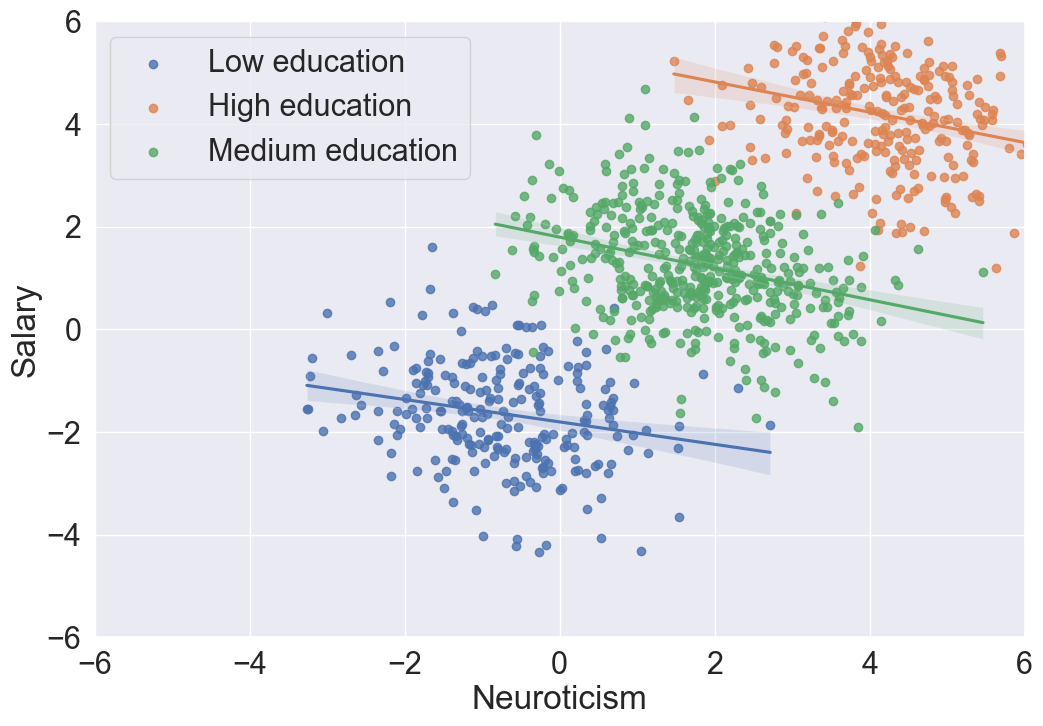

In [ ]:
    fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

    map_z = {
        1: "High education",
        0: "Low education", 
        2: "Medium education",
    }

    plt.xlim(-6,6);
    plt.ylim(-6,6);

    for z in df.Education.unique():
        sns.regplot(data=df[df.Education==z], x="Neuroticism", y="Salary", ax=ax, label=map_z[z])
        
    plt.legend()
    plt.show()